In [ ]:
!pip install torch torchvision --quiet

import os
import time
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils

# Optional: import for download in Colab
try:
    from google.colab import files
except Exception:
    files = None


SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

# 2. Output folder setup
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)
print("Output folder created at:", output_dir.resolve())

Device: cuda
GPU name: Tesla T4
Output folder created at: /content/output


In [ ]:

# 1. Lab Configuration (Hyperparameters)
config = {
    "img_size": 32,        # CIFAR-10 default image size (32x32 pixels)
    "latent_dim": 100,     # Size of the random noise vector (z)
    "batch_size": 128,     # Number of images processed at once
    "lr": 0.0002,          # Learning rate for the optimizer
    "betas": (0.5, 0.999), # Adam optimizer parameters
    "train_epochs": 75,    # Number of times to loop through the dataset
    "num_samples_generate": 8, # Number of final artistic samples (lab asks for 5-10)
    "interpolation_steps": 8   # Number of frames in the smooth transition
}

print("Configuration set:")
for k, v in config.items():
    print(f"  {k}: {v}")

# 2. Data Preparation: CIFAR-10
img_size = config["img_size"]
latent_dim = config["latent_dim"]
batch_size = config["batch_size"]

#  normalizing pixels between -1 and 1
transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]) # Applied to R, G, B channels
])

print("\nDownloading/Loading CIFAR-10 dataset...")
dataset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
print("Dataset loaded. Total samples:", len(dataset))

# 3. Save a grid of dataset samples for your final report
print("Saving dataset sample images (first 16 images) to output folder...")
real_batch = next(iter(loader))
real_images = real_batch[0][:16]  # Grab the first 16 images

# Denormalize from [-1, 1] back to [0, 1] so the image saves with correct colors
vutils.save_image((real_images + 1) / 2, output_dir / "dataset_samples.png", nrow=4, normalize=False)
print("  -> output/dataset_samples.png saved")

Configuration set:
  img_size: 32
  latent_dim: 100
  batch_size: 128
  lr: 0.0002
  betas: (0.5, 0.999)
  train_epochs: 75
  num_samples_generate: 8
  interpolation_steps: 8

Downloading/Loading CIFAR-10 dataset (this may take a moment)...


100%|██████████| 170M/170M [00:03<00:00, 51.3MB/s]


Dataset loaded. Total samples: 50000
Saving dataset sample images (first 16 images) to output folder...
  -> output/dataset_samples.png saved


In [3]:
# --- BLOCK 3: GENERATOR, DISCRIMINATOR, & OPTIMIZERS ---

# 1. Define the Generator (The Artist)
class Generator(nn.Module):
    def __init__(self, latent_dim=100, ngf=128, nc=3):
        super().__init__()
        self.main = nn.Sequential(
            # Input is Z (random noise), going into a transpose convolution
            # State size: (latent_dim) x 1 x 1
            nn.ConvTranspose2d(latent_dim, ngf * 2, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            # State size: (ngf*2) x 4 x 4
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            # State size: (ngf) x 8 x 8
            nn.ConvTranspose2d(ngf, ngf // 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf // 2),
            nn.ReLU(True),

            # State size: (ngf/2) x 16 x 16
            nn.ConvTranspose2d(ngf // 2, nc, 4, 2, 1, bias=False),
            # Output size: (nc) x 32 x 32. Tanh squashes output to [-1, 1]
            nn.Tanh()
        )

    def forward(self, input):
        # Reshape the 1D latent vector into a 3D tensor so convolutions can process it
        return self.main(input.view(input.size(0), input.size(1), 1, 1))

# 2. Define the Discriminator (The Art Critic)
class Discriminator(nn.Module):
    def __init__(self, nc=3, ndf=64):
        super().__init__()
        self.main = nn.Sequential(
            # Input is an image: (nc) x 32 x 32
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # State size: (ndf) x 16 x 16
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # State size: (ndf*2) x 8 x 8
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # State size: (ndf*4) x 4 x 4
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            # Output is a single probability value between 0 and 1
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1) # Flatten the output

# 3. Initialize Models and Optimizers
G = Generator(latent_dim, ngf=128, nc=3).to(device)
D = Discriminator(nc=3, ndf=64).to(device)

print("Generator and Discriminator models initialized and moved to:", device)

# Setup Loss Function and Optimizers
criterion = nn.BCELoss() # Binary Cross Entropy Loss

optimizerD = optim.Adam(D.parameters(), lr=config["lr"], betas=config["betas"])
optimizerG = optim.Adam(G.parameters(), lr=config["lr"], betas=config["betas"])

print("Optimizers and Loss Function ready.")

Generator and Discriminator models initialized and moved to: cuda
Optimizers and Loss Function ready.


In [4]:
# --- BLOCK 4: THE TRAINING LOOP ---

# 1. Check for a pre-trained model to save time
pretrained_path = Path("generator_model.pt")
loaded_pretrained = False

if pretrained_path.exists():
    try:
        G.load_state_dict(torch.load(pretrained_path, map_location=device))
        for p in G.parameters():
            p.requires_grad = False
        G.eval()
        loaded_pretrained = True
        print("Found local pretrained generator_model.pt -> Loaded and frozen generator.")
    except Exception as e:
        print("Found generator_model.pt but failed to load:", e)
        print("Will proceed to train from scratch.")

# 2. The Training Loop (Runs if no model is found)
if not loaded_pretrained:
    epochs = config["train_epochs"]
    print(f"\nNo pretrained generator found. Training DCGAN for {epochs} epochs...")

    # We use a fixed noise vector to watch how the generator improves on the EXACT same input over time
    fixed_noise = torch.randn(64, latent_dim, device=device)

    lossD_val = []
    lossG_val = []
    start_time = time.time()

    for epoch in range(epochs):
        epoch_start = time.time()
        running_lossD = 0.0
        running_lossG = 0.0
        batches = 0

        for i, (real_imgs, _) in enumerate(loader):
            # --- Move data to GPU ---
            real_imgs = real_imgs.to(device)
            b_size = real_imgs.size(0)

            # Real labels = 1, Fake labels = 0
            labels_real = torch.full((b_size,), 1., device=device)
            labels_fake = torch.full((b_size,), 0., device=device)

            # ==========================================
            #   STEP 1: Train Discriminator (The Critic)
            # ==========================================
            D.zero_grad()

            # A. Train with real images
            output_real = D(real_imgs)
            loss_real = criterion(output_real, labels_real)

            # B. Train with fake images
            noise = torch.randn(b_size, latent_dim, device=device)
            fake_imgs = G(noise)
            output_fake = D(fake_imgs.detach()) # Detach so we don't mess with Generator's gradients yet
            loss_fake = criterion(output_fake, labels_fake)

            # Combine losses and update Discriminator weights
            lossD = loss_real + loss_fake
            lossD.backward()
            optimizerD.step()

            # ==========================================
            #   STEP 2: Train Generator (The Artist)
            # ==========================================
            G.zero_grad()

            # The Generator wants the Discriminator to guess "1" (Real) for its fake images
            output_fake2 = D(fake_imgs)
            lossG = criterion(output_fake2, labels_real) # Notice we use labels_real here!

            # Update Generator weights
            lossG.backward()
            optimizerG.step()

            # --- Logging ---
            running_lossD += lossD.item()
            running_lossG += lossG.item()
            batches += 1

            if (i+1) % 200 == 0:
                print(f"  Epoch {epoch+1}/{epochs} | Batch {i+1} | lossD {lossD.item():.4f} | lossG {lossG.item():.4f}")

        # --- End of Epoch Tracking ---
        avgD = running_lossD / max(1, batches)
        avgG = running_lossG / max(1, batches)
        lossD_val.append(avgD)
        lossG_val.append(avgG)
        epoch_time = time.time() - epoch_start
        print(f"Epoch {epoch+1}/{epochs} finished. avg_lossD: {avgD:.4f} avg_lossG: {avgG:.4f} time: {int(epoch_time)}s")

        # Save a sample image to see the progress
        with torch.no_grad():
            sample = G(fixed_noise).cpu()
        vutils.save_image((sample + 1)/2, output_dir / f"epoch_{epoch+1:03d}_sample.png", nrow=8)

    print("\nTraining complete. Total time (s):", int(time.time() - start_time))

    # 3. Save the trained model and loss plot
    torch.save(G.state_dict(), output_dir / "generator_model.pt")
    torch.save(G.state_dict(), "generator_model.pt") # Save to root for quick reloading

    # Freeze the generator now that it is trained
    for p in G.parameters():
        p.requires_grad = False
    G.eval()
    loaded_pretrained = True


No pretrained generator found. Training DCGAN for 75 epochs...
  Epoch 1/75 | Batch 200 | lossD 0.6470 | lossG 4.3216
Epoch 1/75 finished. avg_lossD: 0.4540 avg_lossG: 4.2341 time: 23s
  Epoch 2/75 | Batch 200 | lossD 0.4353 | lossG 3.7014
Epoch 2/75 finished. avg_lossD: 0.5113 avg_lossG: 3.4271 time: 16s
  Epoch 3/75 | Batch 200 | lossD 0.5253 | lossG 2.6213
Epoch 3/75 finished. avg_lossD: 0.6138 avg_lossG: 2.9176 time: 16s
  Epoch 4/75 | Batch 200 | lossD 0.5177 | lossG 2.6649
Epoch 4/75 finished. avg_lossD: 0.6035 avg_lossG: 2.7032 time: 17s
  Epoch 5/75 | Batch 200 | lossD 0.6900 | lossG 2.8928
Epoch 5/75 finished. avg_lossD: 0.6078 avg_lossG: 2.6858 time: 16s
  Epoch 6/75 | Batch 200 | lossD 0.5439 | lossG 2.9466
Epoch 6/75 finished. avg_lossD: 0.6088 avg_lossG: 2.6523 time: 16s
  Epoch 7/75 | Batch 200 | lossD 0.3719 | lossG 2.6593
Epoch 7/75 finished. avg_lossD: 0.5708 avg_lossG: 2.7658 time: 17s
  Epoch 8/75 | Batch 200 | lossD 0.2902 | lossG 2.6400
Epoch 8/75 finished. avg_lo


Generating 8 samples from the trained generator...
Saved generated samples to: generated_samples.png

Performing interpolation between two latent vectors with 8 steps...
Saved interpolation image to: latent_interpolation.png

--- VISUALIZING OUTPUTS ---
1. Random Generated Samples (Task 4):


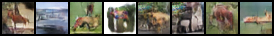


2. Latent Space Interpolation - Smooth Transition (Task 3):


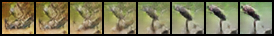

In [5]:
# --- BLOCK 5: GENERATE ARTISTIC OUTPUTS & EXPLORE LATENT SPACE ---

# 1. Generate Random Artistic Samples (Task 4)
num_samples = config["num_samples_generate"] # We set this to 8 earlier
print(f"\nGenerating {num_samples} samples from the trained generator...")

# Create random noise vectors (sliding random numbers under the artist's door)
z_random = torch.randn(num_samples, latent_dim, device=device)

# Turn off gradient tracking since we are just generating, not training
with torch.no_grad():
    generated_samples = G(z_random).cpu()

# Save the generated samples
generated_samples_path = output_dir / "generated_samples.png"
vutils.save_image((generated_samples + 1)/2, generated_samples_path, nrow=num_samples)
print("Saved generated samples to:", generated_samples_path.name)

# 2. Perform Latent Vector Interpolation (Task 3)
steps = config["interpolation_steps"] # We set this to 8 earlier
print(f"\nPerforming interpolation between two latent vectors with {steps} steps...")

# Pick two distinct random points in the latent space (Point A and Point B)
z1 = torch.randn(1, latent_dim, device=device)
z2 = torch.randn(1, latent_dim, device=device)
interp_imgs = []

with torch.no_grad():
    for a in np.linspace(0, 1, steps):
        # Linear interpolation formula: slowly morph from z1 to z2
        z_interp = (1.0 - a) * z1 + a * z2
        interp_imgs.append(G(z_interp).cpu())

# Combine the individual frames into one tensor
interp_imgs = torch.cat(interp_imgs)

# Save the interpolation grid
interp_path = output_dir / "latent_interpolation.png"
vutils.save_image((interp_imgs + 1)/2, interp_path, nrow=steps)
print("Saved interpolation image to:", interp_path.name)

# 3. Visualize the outputs directly in Colab
try:
    from IPython.display import display, Image
    print("\n--- VISUALIZING OUTPUTS ---")
    print("1. Random Generated Samples (Task 4):")
    display(Image(filename=str(generated_samples_path)))
    print("\n2. Latent Space Interpolation - Smooth Transition (Task 3):")
    display(Image(filename=str(interp_path)))
except Exception as e:
    print("Could not display images inline:", e)

In [6]:
# --- BLOCK 6: VERIFY, README, & DOWNLOAD LAB SUBMISSION ---
import os

# 1. Verify required files are present
print("\nChecking final output folder contents:")
required_files = {"generated_samples.png", "latent_interpolation.png", "dataset_samples.png"}
present_files = set([p.name for p in output_dir.iterdir()])
missing_files = required_files - present_files

for p in sorted(output_dir.iterdir()):
    print(f" - {p.name}")

if missing_files:
    print("\nWarning: The following required files are missing:", missing_files)
else:
    print("\nSuccess: All required image files are present!")

# 2. Create a structured README for your lab submission
readme_text = f"""CSET419 - Introduction to Generative AI
Lab 8: Create Artistic Outputs using Neural Art Concepts
Student Name: Gaurav

- Dataset: CIFAR-10 (32x32)
- GAN Architecture: DCGAN (Basic GAN)
- Latent Dimension: {latent_dim}
- Training Epochs: {config['train_epochs']}
- Outputs Included:
  - dataset_samples.png (Original CIFAR-10 training data)
  - generated_samples.png (Task 4: Random artistic outputs)
  - latent_interpolation.png (Task 3: Smooth transitions in latent space)
  - loss_plot.png (If training was executed)
"""

with open(output_dir / "README_lab.txt", "w") as f:
    f.write(readme_text)
print("Saved README_lab.txt inside the output folder.")

# 3. Zip the output folder and trigger download
zip_path = Path("Lab8_Submission.zip")
if zip_path.exists():
    zip_path.unlink() # Delete old zip if it exists to avoid conflicts

print(f"\nCreating {zip_path.name} ...")
os.system(f"zip -r {zip_path} {output_dir}")

# Trigger browser download (Colab specific)
try:
    from google.colab import files
    print("Triggering browser download...")
    files.download(str(zip_path))
except Exception as e:
    print("Automatic download failed. You can manually download the zip from the Colab file sidebar (folder icon on the left).")

print("\nLab completely finished! Great job.")


Checking final output folder contents:
 - dataset_samples.png
 - epoch_001_sample.png
 - epoch_002_sample.png
 - epoch_003_sample.png
 - epoch_004_sample.png
 - epoch_005_sample.png
 - epoch_006_sample.png
 - epoch_007_sample.png
 - epoch_008_sample.png
 - epoch_009_sample.png
 - epoch_010_sample.png
 - epoch_011_sample.png
 - epoch_012_sample.png
 - epoch_013_sample.png
 - epoch_014_sample.png
 - epoch_015_sample.png
 - epoch_016_sample.png
 - epoch_017_sample.png
 - epoch_018_sample.png
 - epoch_019_sample.png
 - epoch_020_sample.png
 - epoch_021_sample.png
 - epoch_022_sample.png
 - epoch_023_sample.png
 - epoch_024_sample.png
 - epoch_025_sample.png
 - epoch_026_sample.png
 - epoch_027_sample.png
 - epoch_028_sample.png
 - epoch_029_sample.png
 - epoch_030_sample.png
 - epoch_031_sample.png
 - epoch_032_sample.png
 - epoch_033_sample.png
 - epoch_034_sample.png
 - epoch_035_sample.png
 - epoch_036_sample.png
 - epoch_037_sample.png
 - epoch_038_sample.png
 - epoch_039_sample.png
 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Lab completely finished! Great job.
